In [605]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [627]:
import json
from pprint import pprint

paths_path = r"info\paths2.json"
with open(paths_path, 'r') as f:
    paths = json.load(f)

# paths = {
#     "minmax og": r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128',
#     "zscore std dev 0": r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128',
#     "zscore std dev 1e-8": r'jobs\20251122_150635\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000',
#     "zscore std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "zscore std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "slopes on 0 std dev": r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000",
#     "log on std dev 0": r"jobs\20251121_234325\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "log on std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234345\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "log on std dev 1e-7": r"jobs\20251121_234356\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 1e-8": r"jobs\20251122_150633\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234746\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251121_234754\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 0": r"A:\Projects\DM + RL\RL\jobs\20251121_234802\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
# }

model_name = "tiny cnn do0.1 wd5e-4"

path = paths[model_name]
# path = r'jobs\20251111_165459\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251115_225402\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h1024-512-256-images'
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012420\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012429\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"

# model1
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# # model2
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# model3 (slopes)
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000"

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [628]:
# loading the model in

import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [629]:
if metrics_data['args']['fc1_final_activation'] != 'none':
    raise DeprecationWarning("This model has a poor final activation and is deprecated for evaluation.")

In [630]:
metrics_data['args']

{'datapath': 'data/dataset100K25M_LA.pkl',
 'model_type': 'fc1',
 'norm': 'zscore',
 'epochs': 2000,
 'batch_size': 2048,
 'lr': 0.001,
 'val_split': 0.2,
 'seed': 42,
 'data_cutoff': None,
 'cpu_only': True,
 'weight_decay': 0.0005,
 'split_vector': False,
 'mag_cost': 1.0,
 'fc1_hidden': [64],
 'fc1_activation': 'leaky_relu',
 'fc1_final_activation': 'none',
 'fc1_dropout': 0.1,
 'fc1_encoder_enabled': True,
 'fc1_filter_sizes': [3, 3, 3],
 'fc1_filter_channels': [8, 16, 32],
 'fc1_final_embedding_size': 16,
 'fc1_final_embedding_channels': 32,
 'cnn1_img_out': 32,
 'cnn1_dm_hidden': 32,
 'tf1_patch_size': 8,
 'tf1_dim': 128,
 'tf1_depth': 4,
 'tf1_heads': 4,
 'tf1_mlp_dim': 256,
 'tf1_attn_dropout': 0.0,
 'tf1_emb_dropout': 0.0,
 'tf1_use_cls_token': False,
 'train_type': 'images',
 'resume': None,
 'freeze': False,
 'out_dir': '/scratch/network/ak9088/NASA-RL-Wavefront-Control/RL/jobs/20251222_203559/exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h64-images-wd0.0005-do0.1'}

In [631]:
metrics_data

{'args': {'datapath': 'data/dataset100K25M_LA.pkl',
  'model_type': 'fc1',
  'norm': 'zscore',
  'epochs': 2000,
  'batch_size': 2048,
  'lr': 0.001,
  'val_split': 0.2,
  'seed': 42,
  'data_cutoff': None,
  'cpu_only': True,
  'weight_decay': 0.0005,
  'split_vector': False,
  'mag_cost': 1.0,
  'fc1_hidden': [64],
  'fc1_activation': 'leaky_relu',
  'fc1_final_activation': 'none',
  'fc1_dropout': 0.1,
  'fc1_encoder_enabled': True,
  'fc1_filter_sizes': [3, 3, 3],
  'fc1_filter_channels': [8, 16, 32],
  'fc1_final_embedding_size': 16,
  'fc1_final_embedding_channels': 32,
  'cnn1_img_out': 32,
  'cnn1_dm_hidden': 32,
  'tf1_patch_size': 8,
  'tf1_dim': 128,
  'tf1_depth': 4,
  'tf1_heads': 4,
  'tf1_mlp_dim': 256,
  'tf1_attn_dropout': 0.0,
  'tf1_emb_dropout': 0.0,
  'tf1_use_cls_token': False,
  'train_type': 'images',
  'resume': None,
  'freeze': False,
  'out_dir': '/scratch/network/ak9088/NASA-RL-Wavefront-Control/RL/jobs/20251222_203559/exp-fc1-zscore-ep2000-bs2048-lr1e-3-s4

In [632]:
from archs.fc1 import FC1
import torch
state_obj = torch.load(checkpoint_path, map_location='cpu')
if isinstance(state_obj, dict):
    if 'state_dict' in state_obj:
        state_dict = state_obj['state_dict']
    elif 'model_state_dict' in state_obj:
        state_dict = state_obj['model_state_dict']
    else:
        state_dict = state_obj
else:
    state_dict = state_obj

if "resnet50" in model_name:
    from archs.resnet50_fc import ResNet50FC
    model = ResNet50FC(
        output_dim=metrics_data['output_dim'], 
        input_dim=3
        )
    model.load_state_dict(state_dict)
else:
    fc1_args = metrics_data['args']
    requested_encoder = fc1_args.get('fc1_encoder_enabled', False)
    state_has_encoder = any(k.startswith('encoder.') for k in state_dict.keys())
    if state_has_encoder != requested_encoder:
        if state_has_encoder:
            print("Checkpoint includes encoder weights; enabling encoder to match saved model.")
        else:
            print("Checkpoint has no encoder weights; disabling encoder to match saved model.")
        encoder_enabled = state_has_encoder
    else:
        encoder_enabled = requested_encoder
    model = FC1(
        final_output_dim=metrics_data['output_dim'], 
        image_input_shape=metrics_data['input_shape'], 
        hidden_layers=fc1_args['fc1_hidden'], 
        activation=fc1_args['fc1_activation'],
        final_activation=fc1_args['fc1_final_activation'],
        dropout=fc1_args.get('fc1_dropout', 0.0),
        encoder_enabled=encoder_enabled,
        filter_sizes=fc1_args.get('fc1_filter_sizes', None),
        filter_channels=fc1_args.get('fc1_filter_channels', None),
        final_embedding_size=fc1_args.get('fc1_final_embedding_size', None),
        final_embedding_channels=fc1_args.get('fc1_final_embedding_channels', None),
        )
    print(f"model: {model}")
    missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
    if missing_keys:
        print(f"Missing keys when loading checkpoint: {missing_keys}")
    if unexpected_keys:
        print(f"Unexpected keys when loading checkpoint: {unexpected_keys}")
model.eval()

model: FC1(
  (encoder): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): AdaptiveAvgPool2d(output_size=(16, 16))
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (final_net): Sequential(
    (0): Linear(in_features=8192, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=25, bias=True)
    (4): Identity()
  )
)


FC1(
  (encoder): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): AdaptiveAvgPool2d(output_size=(16, 16))
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (final_net): Sequential(
    (0): Linear(in_features=8192, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=25, bias=True)
    (4): Identity()
  )
)

In [633]:
fc1_args['fc1_activation']

'leaky_relu'

In [634]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 532009


In [635]:
from environment import CoronagraphEnvironment
import copy


def revive_jsonable(obj):
    if isinstance(obj, dict):
        if obj.get("__type") == "slice":
            return slice(obj.get("start"), obj.get("stop"), obj.get("step"))
        return {k: revive_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [revive_jsonable(v) for v in obj]
    return obj


raw_env_config = metrics_data['dataset_meta']['environment_config']
env_config = revive_jsonable(copy.deepcopy(raw_env_config))
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')
if 'env_delta_t' in env_config:
    env_config['delta_t'] = env_config.pop('env_delta_t')

env_config['obs_noise_level'] = 0.0  # disable observation noise for evaluation

env = CoronagraphEnvironment(**env_config)

initializing coronagraph env. might take a minute.


In [636]:
env_config

{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 7,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_noise_level': 0.0,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'orthogonal',
 'mode_range': slice(0, 25, None),
 'delta_t': 0.001}

In [637]:
print(f"basis type: {env.basis}")
print(f"for consistency, please ensure models were trained on the same basis.")

basis type: orthogonal
for consistency, please ensure models were trained on the same basis.


In [638]:
import matplotlib as mpl

TEXT_COLOR = 'black'

mpl.rcParams['text.color'] = TEXT_COLOR
mpl.rcParams['axes.labelcolor'] = TEXT_COLOR # For axis labels
mpl.rcParams['xtick.color'] = TEXT_COLOR    # For x-axis tick labels
mpl.rcParams['ytick.color'] = TEXT_COLOR    # For y-axis tick labels


### Model history

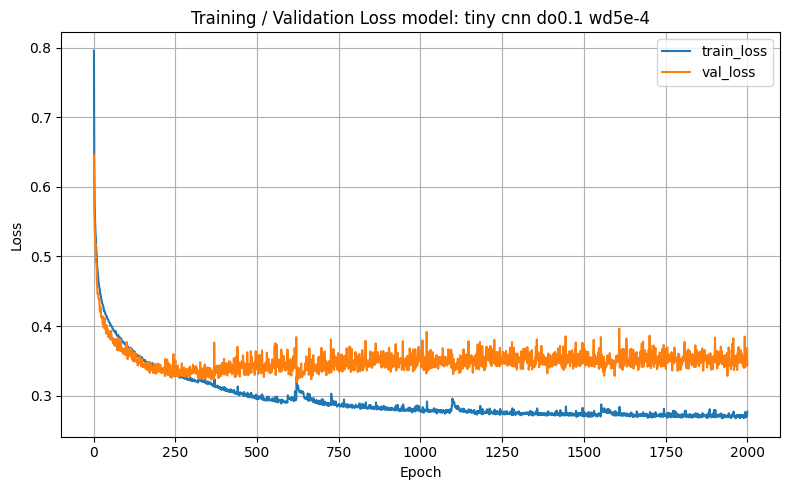

Minimum Validation Loss: 0.31946620607376097
Minimum Training Loss: 0.2676246328830719


In [639]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(f'Training / Validation Loss model: {model_name}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'images/training_validation_loss {metrics_data["args"]["fc1_hidden"]}.png', transparent=True)
plt.show()

print(f"Minimum Validation Loss: {min(val) if val else 'N/A'}")
print(f"Minimum Training Loss: {min(train) if train else 'N/A'}")

In [626]:
env_config

{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 7,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_noise_level': 0.0,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'orthogonal',
 'mode_range': slice(0, 25, None),
 'delta_t': 0.001}

### Model properties:

In [500]:
from train_job import NORMALIZERS
model.eval()
delta_t = 1e-3 # metrics_data['dataset_meta']['dataset_config']['delta_t']
delta_t *= 100 if model_name != "linear model" else 1 # due to a data scaling error, need this to compensate.
# dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
train_type = metrics_data['args'].get('train_type', 'images')
slopes_train = False # (train_type == "slopes")
split_vector = metrics_data['args'].get('split_vector', False)
print(f"Using split vector: {split_vector}")
print(f"Using slopes: {slopes_train}")

norm_func_name = metrics_data['x_norm']['type']
if norm_func_name == "log+zscore": norm_func_name = "log"

x_norm_func = NORMALIZERS[norm_func_name]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

num_modes = env_config['num_modes']

Using split vector: False
Using slopes: False


In [501]:
alphas = None

In [512]:
import tqdm

regenerate_properties = True 


noise_levels = metrics_data['dataset_meta']['dataset_config']['dm_random_noise'] #[1e-6]
repetitions = 10
loops = 1

if regenerate_properties:
    noise_levels = np.atleast_1d(np.asarray(noise_levels, dtype=float))
    samples = noise_levels.shape[0]
    repetitions = int(repetitions)
    loops = int(max(1, loops))
    
    cos_history = np.zeros((samples, repetitions, loops))
    contrast_history = np.zeros((samples, repetitions, loops + 1))
    predictions = np.zeros((samples, repetitions, num_modes))
    truths = np.zeros((samples, repetitions, num_modes))
    
    model_device = next(model.parameters()).device
    use_resnet_backend = "resnet50" in model_name.lower()
    
    def prepare_tensor(imgs):
        imgs = np.asarray(imgs, dtype=np.float32)
        imgs = np.expand_dims(imgs, axis=0)
        imgs_norm, _ = x_norm_func(imgs, **params)
        if use_resnet_backend:
            tensor = torch.from_numpy(imgs_norm).float()
        else:
            tensor = torch.from_numpy(np.transpose(imgs_norm, (0, 2, 3, 1))).float()
        return tensor.to(model_device)
    
    def get_model_output(imgs):
        with torch.no_grad():
            input_tensor = prepare_tensor(imgs)
            y_pred = model(input_tensor)
            y_pred = y_pred.squeeze(0).detach().cpu().numpy()
            if split_vector:
                vec_part = y_pred[:-1]
                work_pred = vec_part / (np.linalg.norm(vec_part) + 1e-12)
            else:
                work_pred = y_pred
        return work_pred * y_std + y_mean
    
    alpha_lookup = None
    if split_vector and 'alphas' in locals() and alphas is not None:
        alpha_lookup = np.asarray(alphas)
    
    for i, noise in enumerate(tqdm.tqdm(noise_levels, desc="noise sweep")):
        for j in range(repetitions):
            env.deformable_mirror.flatten()
            env.set_random_dm(noise=noise)
            initial_dm = np.array(env.deformable_mirror.actuators.copy())
            initial_contrast = env.get_contrast(delta_t=1e15)
            contrast_history[i, j, 0] = np.log10(initial_contrast)
            
            for loop_idx in range(loops):
                state_before = np.array(env.deformable_mirror.actuators.copy())
                imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
                work_pred = get_model_output(imgs)
                
                if split_vector and alpha_lookup is not None:
                    alpha_value = np.squeeze(alpha_lookup[i]) if alpha_lookup.ndim > 1 else alpha_lookup[i]
                    work_pred = work_pred * alpha_value
                
                net_action = state_before - work_pred
                env.deformable_mirror.flatten()
                env.deformable_mirror.actuators = net_action
                
                cos_sim = np.dot(work_pred, state_before) / (np.linalg.norm(work_pred) * np.linalg.norm(state_before))

                cos_num = np.dot(work_pred, state_before)
                cos_den = (np.linalg.norm(work_pred) * np.linalg.norm(state_before)) + 1e-40
                cos_history[i, j, loop_idx] = cos_num / cos_den
                
                updated_contrast = env.get_contrast(delta_t=1e15)
                contrast_history[i, j, loop_idx + 1] = np.log10(updated_contrast)
            
            truths[i, j, :] = initial_dm
            predictions[i, j, :] = initial_dm - env.deformable_mirror.actuators
            
    cos_similarities_raw = cos_history[:, :, -1]
    cos_similarities = np.mean(cos_similarities_raw, axis=1)
    cos_similarities_std = np.std(cos_similarities_raw, axis=1)
    cos_similarities_25 = np.percentile(cos_similarities_raw, 25, axis=1)
    cos_similarities_75 = np.percentile(cos_similarities_raw, 75, axis=1)
    
    initial_contrasts_raw = contrast_history[:, :, 0]
    final_contrasts_raw = contrast_history[:, :, -1]
    initial_contrasts = np.mean(initial_contrasts_raw, axis=1)
    initial_contrasts_std = np.std(initial_contrasts_raw, axis=1)
    final_contrasts = np.mean(final_contrasts_raw, axis=1)
    final_contrasts_std = np.std(final_contrasts_raw, axis=1)
    
    evaluation_stats = {
        "noise_levels": noise_levels.tolist(),
        "loops": loops,
        "repetitions": repetitions,
        "cosine_similarity": {
            "mean": cos_similarities.tolist(),
            "std": cos_similarities_std.tolist(),
            "p25": cos_similarities_25.tolist(),
            "p75": cos_similarities_75.tolist(),
        },
        "initial_contrast_log10": {
            "mean": initial_contrasts.tolist(),
            "std": initial_contrasts_std.tolist()
        },
        "final_contrast_log10": {
            "mean": final_contrasts.tolist(),
            "std": final_contrasts_std.tolist()
        }
    }
    pprint(evaluation_stats)

noise sweep: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]

{'cosine_similarity': {'mean': [0.9831238663468517],
                       'p25': [0.9847461097496056],
                       'p75': [0.9927077446486504],
                       'std': [0.01999732754051534]},
 'final_contrast_log10': {'mean': [-6.28996987427619],
                          'std': [0.18129905745160263]},
 'initial_contrast_log10': {'mean': [-4.072301426157258],
                            'std': [0.11992186731467137]},
 'loops': 1,
 'noise_levels': [1e-07],
 'repetitions': 10}


$$\text{argmin}_{\alpha} (\vert \vert \alpha X -  y \vert \vert)$$

$$= \text{argmin}_{\alpha} (\sum_{i=1}^{p} (\alpha x_i - y_i)^2)$$

$$ \text{Take partial w.r.t } \alpha$$

$$ \frac{\partial}{\partial \alpha} (\sum_{i=1}^{p} (\alpha x_i - y_i)^2) = \sum_{i=1}^{p} 2(\alpha x_i - y_i)(x_i)$$

$$ \text{Set this equal to 0} $$

$$ \sum_{i=1}^{p} 2(\alpha x_i - y_i)(x_i) = 0 $$

$$ \sum_{i=1}^{p} (\alpha x_i^2 - y_i x_i) = 0 $$

$$ \sum_{i=1}^{p} \alpha x_i^2 - \sum_{i=1}^{p} y_i x_i = 0 $$

$$ \sum_{i=1}^{p} \alpha x_i^2 = \sum_{i=1}^{p} y_i x_i $$

$$ \alpha \sum_{i=1}^{p} x_i^2 = \sum_{i=1}^{p} y_i x_i $$

$$ \alpha = \frac{\sum_{i=1}^{p} y_i x_i}{\sum_{i=1}^{p} x_i^2} $$

### Visualize residuals

In [100]:
residuals = truths - predictions
residuals = residuals.squeeze(0)

In [172]:
if split_vector:
    # Find optimal alpha
    alphas = []
    for x, y in zip(predictions, truths):
        dots = np.diag(x @ y.T)

        squares = np.diag(x @ x.T)

        alpha = dots / squares
        alphas.append(alpha)
    
    alphas = np.array(alphas)

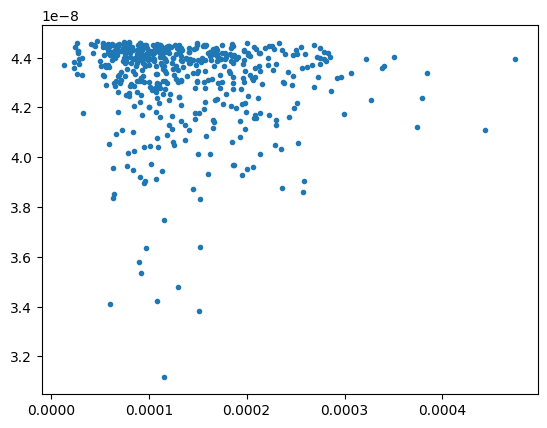

In [173]:
plt.plot(initial_contrasts_raw, alphas.squeeze(), '.')

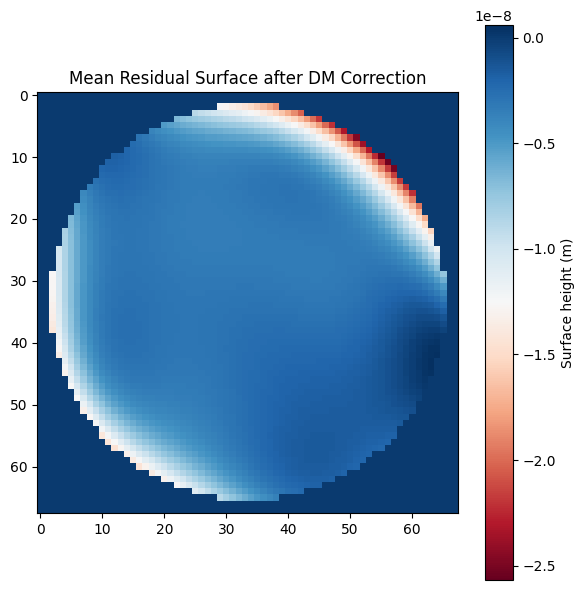

In [133]:
mean_residual_surface = np.zeros_like(env.deformable_mirror.surface)

for residual in residuals:
    env.deformable_mirror.flatten()
    env.deformable_mirror.actuators = residual
    surface = env.deformable_mirror.surface
    mean_residual_surface += surface / residuals.shape[0]

surface_dim = surface.shape[0]
square_dim = np.sqrt(surface_dim).astype(int)
mean_residual_surface = mean_residual_surface.reshape((square_dim, square_dim))
plt.figure(figsize=(6,6))
plt.imshow(mean_residual_surface, cmap='RdBu')
plt.colorbar(label='Surface height (m)')
plt.title('Mean Residual Surface after DM Correction')
plt.tight_layout()
plt.savefig(f'images/mean_residual_surface {metrics_data["args"]["fc1_hidden"]}.png', transparent=True)
plt.show()


In [ ]:
import pickle
from time import time

if regenerate_properties:
    with open(f'evals/LA_evals/eval_{model_name}.pkl', 'wb') as f:
        pickle.dump({
            "noise_levels": noise_levels,
            "loops": loops,
            "repetitions": repetitions,
            "initial_contrasts": initial_contrasts,
            "initial_contrasts_std": initial_contrasts_std,
            "final_contrasts": final_contrasts,
            "final_contrasts_std": final_contrasts_std,
            "cos_similarities": cos_similarities,
            "cos_similarities_std": cos_similarities_std,
            "cos_similarities_25": cos_similarities_25,
            "cos_similarities_75": cos_similarities_75,
            "cos_similarities_raw": cos_similarities_raw,
            "predictions": predictions,
            "truths": truths,
            "loop_contrast_history": contrast_history,
            "loop_cosine_history": cos_history
        }, f)
else:
    with open(f'evals/eval_{model_name}.pkl', 'rb') as f:
        eval_data = pickle.load(f)
        noise_levels = np.asarray(eval_data["noise_levels"])
        loops = eval_data.get("loops", loops if 'loops' in locals() else 1)
        repetitions = eval_data.get("repetitions", repetitions if 'repetitions' in locals() else 1)
        initial_contrasts = eval_data["initial_contrasts"]
        final_contrasts = eval_data["final_contrasts"]
        cos_similarities = eval_data["cos_similarities"]
        predictions = eval_data["predictions"]
        truths = eval_data["truths"]
        initial_contrasts_std = eval_data.get("initial_contrasts_std")
        final_contrasts_std = eval_data.get("final_contrasts_std")
        cos_similarities_std = eval_data.get("cos_similarities_std")
        cos_similarities_25 = eval_data.get("cos_similarities_25")
        cos_similarities_75 = eval_data.get("cos_similarities_75")
        cos_similarities_raw = eval_data.get("cos_similarities_raw")
        contrast_history = eval_data.get("loop_contrast_history")
        cos_history = eval_data.get("loop_cosine_history")

In [357]:
print(f"Final contrasts: {final_contrasts}")
print(f"Final contrasts std dev: {final_contrasts_std}")
print(f"Cosine similarities: {cos_similarities}")
print(f"Cosine similarities std dev: {cos_similarities_std}")
print(f"Cosine similarities 25th percentile: {cos_similarities_25}")
print(f"Cosine similarities 75th percentile: {cos_similarities_75}")

Final contrasts: [-2.38992524]
Final contrasts std dev: [0.27526195]
Cosine similarities: [0.71038037]
Cosine similarities std dev: [0.11648471]
Cosine similarities 25th percentile: [0.63316884]
Cosine similarities 75th percentile: [0.80010226]


In [ ]:
## Some derived metrics
contrast_improvements = np.exp(initial_contrasts) / np.exp(final_contrasts)

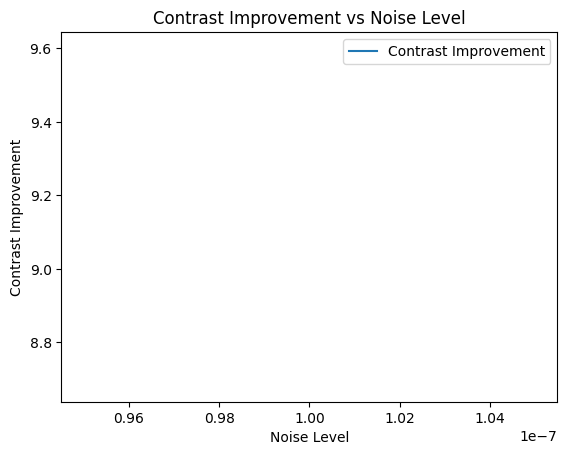

In [53]:
## Visualizations
plt.plot(noise_levels, contrast_improvements, label='Contrast Improvement')
plt.xlabel('Noise Level')
plt.ylabel('Contrast Improvement')
plt.title('Contrast Improvement vs Noise Level')
plt.legend()
plt.show()

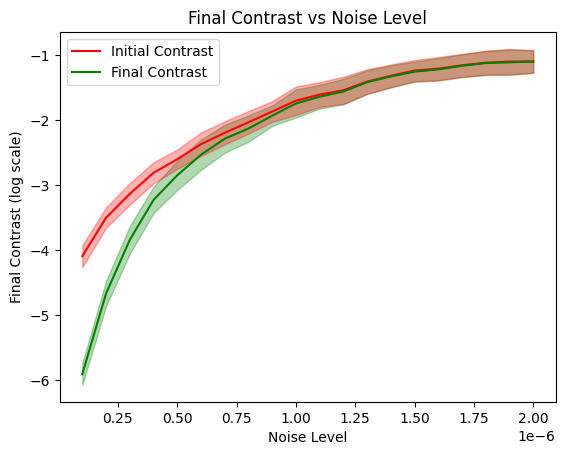

In [27]:
plt.plot(noise_levels, initial_contrasts, label='Initial Contrast', color="red")
plt.plot(noise_levels, final_contrasts, label='Final Contrast', color="green")
plt.fill_between(noise_levels, final_contrasts - final_contrasts_std, final_contrasts + final_contrasts_std, alpha=0.3, color="green")
plt.fill_between(noise_levels, initial_contrasts - initial_contrasts_std, initial_contrasts + initial_contrasts_std, alpha=0.3, color="red")
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast (log scale)')
plt.title('Final Contrast vs Noise Level')
plt.legend()
plt.show()

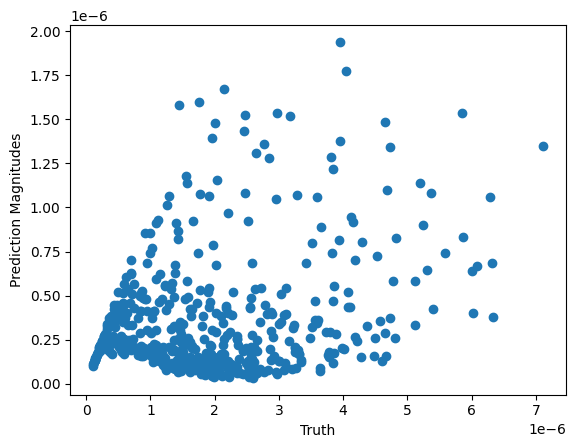

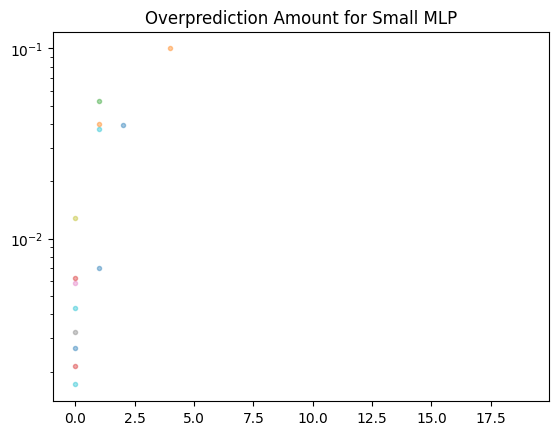

In [28]:
prediction_magnitudes = np.linalg.norm(predictions, axis=1)
truth_magnitudes = np.linalg.norm(truths, axis=1)

plt.scatter(truth_magnitudes, prediction_magnitudes)
plt.ylabel("Prediction Magnitudes")
plt.xlabel("Truth")
plt.show()

overprediction_amount = np.subtract(prediction_magnitudes, truth_magnitudes) / truth_magnitudes
median_overprediction = np.median(overprediction_amount)
plt.plot(overprediction_amount, '.', alpha=0.4)
plt.title("Overprediction Amount for Small MLP")
plt.axhline(y=np.mean(overprediction_amount), color="red", linestyle='--')
plt.yscale('log')
plt.show()


In [89]:
converged_prediction_vector = None

### Generating a residual dataset

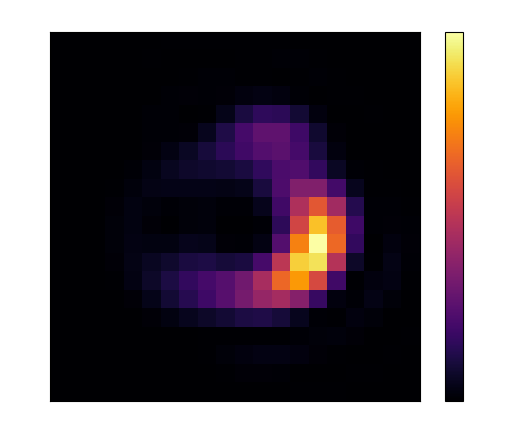

100%|██████████| 50/50 [00:02<00:00, 24.58it/s]



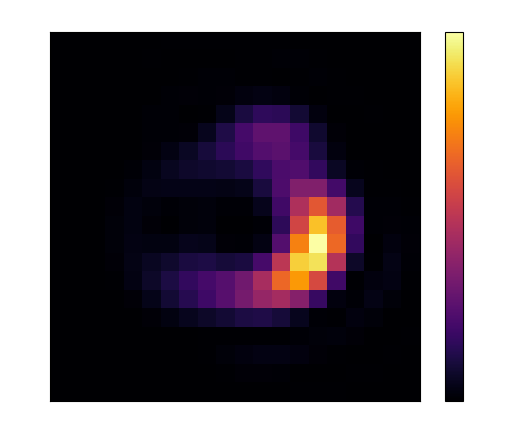

100%|██████████| 50/50 [00:02<00:00, 24.58it/s]



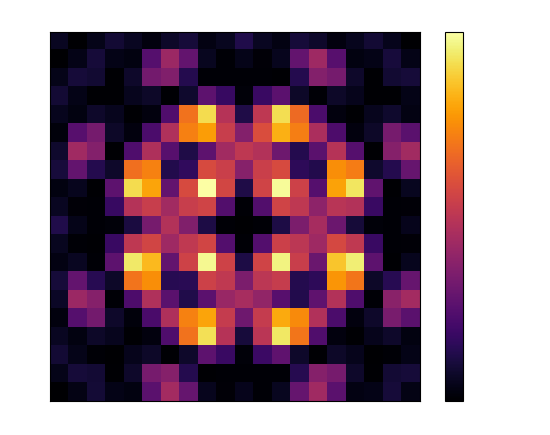

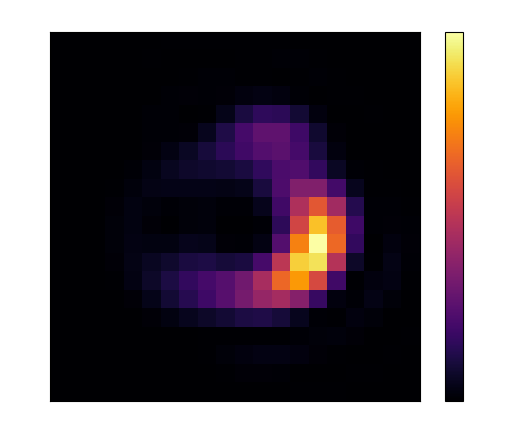

100%|██████████| 50/50 [00:02<00:00, 24.58it/s]



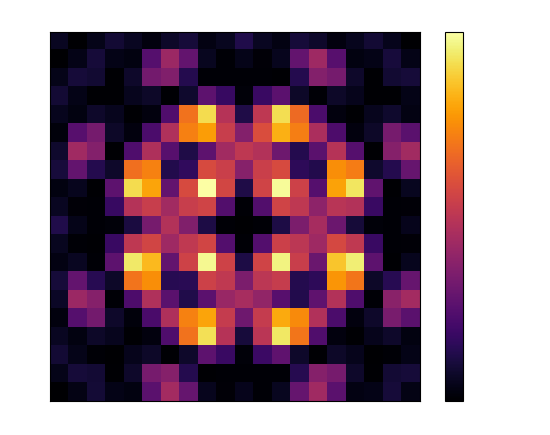

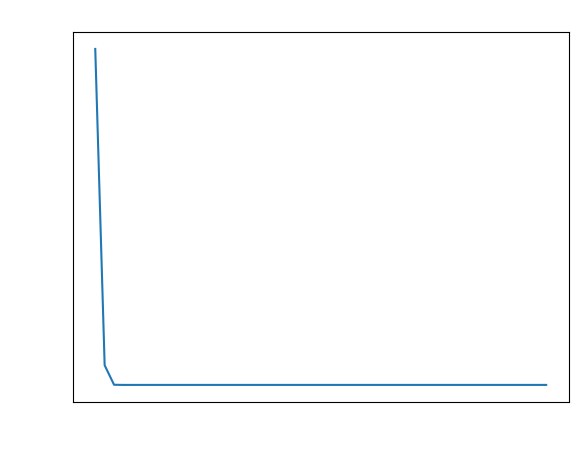

Final contrast after 50 iterations: 6.004110984712864e-09


In [ ]:
from train_job import NORMALIZERS
import tqdm


# model.eval()
# delta_t = 1e-3 # metrics_data['dataset_meta']['dataset_config']['delta_t']
# delta_t *= 100 if model_name != "linear model" else 1 # due to a data scaling error, need this to compensate.
# # dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
# train_type = metrics_data['args'].get('train_type', 'images')
# slopes_train = False # (train_type == "slopes")
# split_vector = metrics_data['args'].get('split_vector', False)
# print(f"Using split vector: {split_vector}")
# print(f"Using slopes: {slopes_train}")

# norm_func_name = metrics_data['x_norm']['type']
# if norm_func_name == "log+zscore": norm_func_name = "log"

# x_norm_func = NORMALIZERS[norm_func_name]
# params = metrics_data['x_norm'].copy()
# params.pop('type')

# y_mean = metrics_data['y_norm']['mean']
# y_std = metrics_data['y_norm']['std']

# num_modes = env_config["num_modes"]

noise_level = 1e-7
repetitions = 50

contrast_iteration = []
model_device = next(model.parameters()).device
use_resnet_backend = "resnet50" in model_name.lower()

def get_model_output(imgs):
    with torch.no_grad():
        imgs = np.asarray(imgs, dtype=np.float32)
        imgs = np.expand_dims(imgs, axis=0)
        imgs_norm, _ = x_norm_func(imgs, **params)
        if use_resnet_backend:
            input_tensor = torch.from_numpy(imgs_norm).float()
        else:
            hwc = np.transpose(imgs_norm, (0, 2, 3, 1))
            input_tensor = torch.from_numpy(hwc).float()
        input_tensor = input_tensor.to(model_device)

        y_pred = model(input_tensor)
        y_pred = y_pred.squeeze(0).detach().cpu().numpy()

        if split_vector:
            vec_part = y_pred[:-1]
            magnitude_part = y_pred[-1]
            work_pred = vec_part
            work_pred /= np.linalg.norm(vec_part)
        else:
            work_pred = y_pred
    
    work_pred = work_pred * y_std + y_mean

    return work_pred

env.deformable_mirror.flatten()
env.set_random_dm(noise=noise_level)

e_img = env.get_camera_image(delta_t=1e-3, noise_enabled=False)
plt.imshow(e_img, cmap='inferno')
plt.colorbar(label='Intensity')
plt.title('Initial Diversity Image before DM Corrections')
plt.savefig(f'images/initial_diversity_image_{model_name}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

for i in tqdm.tqdm(range(repetitions)):
    
    original = np.array(env.deformable_mirror.actuators.copy())
    contrast = env.get_contrast(delta_t=1e15)
    contrast_iteration.append(contrast)    
    imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
    
    work_pred = get_model_output(imgs)
    net_action = original - work_pred

    if converged_prediction_vector is not None:
        net_action -= converged_prediction_vector

    env.deformable_mirror.flatten()
    env.deformable_mirror.actuators = net_action



    # final_contrast = env.get_contrast(delta_t=1e15)
    # final_contrasts_raw.append(final_contrast)

        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=noise_level)
        # original = np.array(env.deformable_mirror.actuators.copy())
        # initial_contrast = env.get_contrast(delta_t=1e15)
        # initial_contrasts_raw.append(initial_contrast)

        # imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

        # work_pred = get_model_output(imgs)
        # # work_pred *= alphas[i]
            
        # truths[i, j, :] = original
        # predictions[i, j, :] = work_pred

        # net_action = original - work_pred

        # env.deformable_mirror.flatten()
        # env.deformable_mirror.actuators = net_action
        # final_contrast = env.get_contrast(delta_t=1e15)
        # final_contrasts_raw.append(final_contrast)

        # cos_sim = np.dot(work_pred, original) / (np.linalg.norm(work_pred) * np.linalg.norm(original))
        # cos_similarities_raw.append(cos_sim)

if converged_prediction_vector is None:
    converged_prediction_vector = env.deformable_mirror.actuators.copy()

e_img = env.get_camera_image(delta_t=1e-3, noise_enabled=False)
plt.imshow(e_img, cmap='inferno')
plt.colorbar(label='Intensity')
plt.title('Final Diversity Image after DM Corrections')
plt.savefig(f'images/final_diversity_image_{model_name}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

plt.plot(contrast_iteration[1:])
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Contrast')
plt.title('Contrast over Iterations')
plt.savefig(f'images/contrast_over_iterations_{model_name}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

print(f"Final contrast after {repetitions} iterations: {contrast_iteration[-1]}")